In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import pandas as pd

# Define the exact character column widths for the first few columns
# Column 1 (ID): 2 chars, Column 2 (Wavenumber): 12 chars, etc.
col_widths = [3, 12, 10]  # Adjust remaining widths based on your exact schema

df = pd.read_fwf("C:/Users/ezra/OneDrive - Delft University of Technology/School/Universiteit/BEP/Raw Data/HITRAN_v2.txt", widths=col_widths, header=None)
print(df)

         0             1           2
0      # T  he list of s  pectral li
1      # U  SA model, me  an latitud
2      # W  avenumber ra  nge: 50.00
3      #MI       WN,cm-1    S,cm/mol
4       15     50.005642   3.114e-28
...    ...           ...         ...
90655   11  14983.182768   2.455e-28
90656   11  14985.899197   9.114e-28
90657   11  14998.393940   8.296e-28
90658   11  14999.281809   1.410e-28
90659   11  14999.311364   5.896e-28

[90660 rows x 3 columns]


[[1.50000000e+01 5.00056420e+01 3.11400000e-28]
 [1.50000000e+01 5.00370000e+01 6.68900000e-28]
 [1.40000000e+01 5.02765800e+01 1.51600000e-25]
 ...
 [1.10000000e+01 1.49983939e+04 8.29600000e-28]
 [1.10000000e+01 1.49992818e+04 1.41000000e-28]
 [1.10000000e+01 1.49993114e+04 5.89600000e-28]]


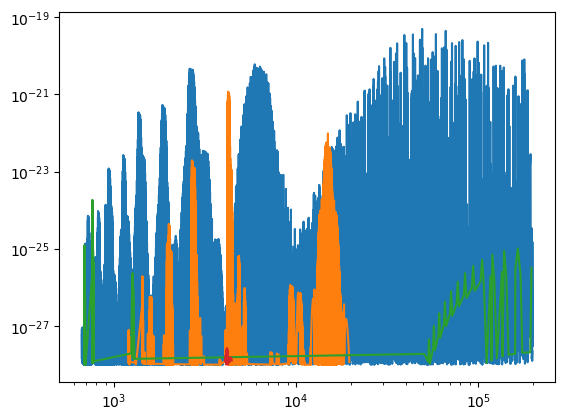

In [51]:
data = np.float64(np.array(df)[4:])

#molecule clips
H2O_clip = np.nonzero(np.floor(data[:,0]/10) == 1)
CO2_clip = np.nonzero(np.floor(data[:,0]/10) == 2)
O2_clip = np.nonzero(np.floor(data[:,0]/10) == 7)
N2_clip = np.nonzero(np.floor(data[:,0]/10) == 22)

#clipping and converting S to alpha by multiplying by 
H2O = data[H2O_clip]
CO2 = data[CO2_clip]
O2 = data[O2_clip]
N2 = data[N2_clip]

print(H2O)

plt.plot(1e7/H2O[:,1],H2O[:,2])
plt.plot(1e7/CO2[:,1],CO2[:,2])
plt.plot(1e7/O2[:,1],O2[:,2])
plt.plot(1e7/N2[:,1],N2[:,2])
plt.yscale('log')
plt.xscale('log')